# Plotting DMFit data

`SpinPlots` provides functionality to easily plot fits of NMR data done using [DMFit](https://nmr.cemhti.cnrs-orleans.fr/). Both 1D and 2D spectra are supported, including overlays, stacked views, and grid layouts.

## Plotting 1D fits

To use `Spinplots` functions, you first need to export your 1D `DMFit` data, as follows:

1. Navigate to the menu: `Decomposition → Export spec, model with all lines → Export as Ascii File`.
2. **Important**: Ensure the file extension is either `.hz` (for data in Hz) or `.ppm` (for data in ppm).

The example below used data exported from a [DMFit example](https://nmr.cemhti.cnrs-orleans.fr/Dmfit/Howto/1D_GLlines.aspx) showing a <sup>31</sup>P NMR spectrum showing overlapping peaks.

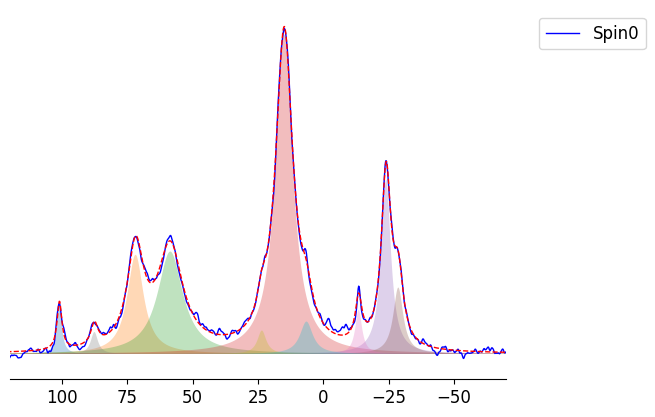

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from spinplots.io import read_nmr

dmfit_data = read_nmr("../../data/DMFit/overlapping_spe_fit.ppm",
                      provider="dmfit")
dmfit_data.plot(xlim=(120, -70))

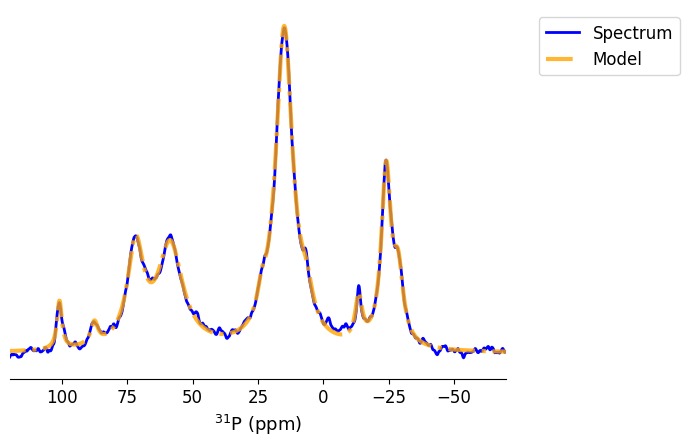

In [2]:
dmfit_data.plot(
    xlim=(120, -70),
    xaxislabel="$^{31}$P (ppm)",    # Add a label to the x-axis
    linewidth=2,                    # Increase width of spectrum
    model_linewidth=3,              # Increase width of model
    model_linestyle='-.',           # Change the linestyle of the model
    model_color='orange',           # Change the color of the model
    model_alpha=0.8,                # Transparency of the model
    deconv_show=False,              # Hide the deconvolution curves
    labels=["Spectrum", "Model"],   # Add a legend
)

### Overlaying multiple 1D DMFit spectra

Multiple DMFit exports can be loaded and plotted together. Each spectrum is shown with its own color:

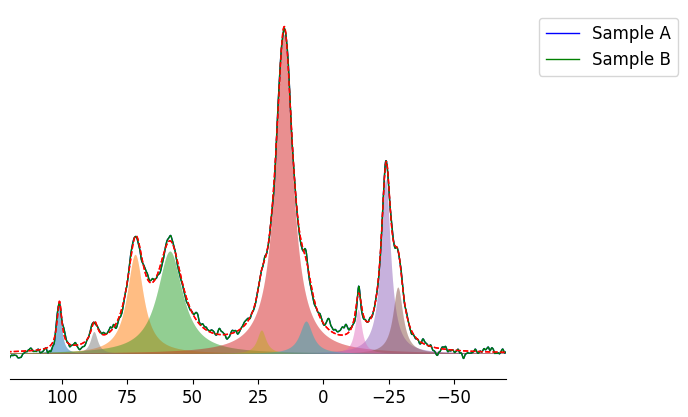

In [3]:
# Load the same file twice for demonstration (use different exports in practice)
multi_dmfit = read_nmr(
    ["../../data/DMFit/overlapping_spe_fit.ppm", "../../data/DMFit/overlapping_spe_fit.ppm"],
    provider="dmfit",
    tags=["Sample A", "Sample B"],
)
multi_dmfit.plot(
    color=["blue", "green"],
    xlim=(120, -70),
    labels=["Sample A", "Sample B"],
)

### Stacked 1D DMFit spectra

Use `stacked=True` to offset spectra vertically, which is useful for comparing lineshapes:

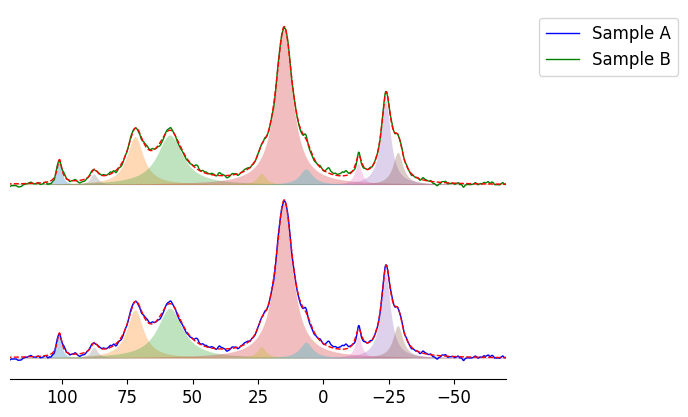

In [4]:
multi_dmfit.plot(
    color=["blue", "green"],
    xlim=(120, -70),
    stacked=True,
    labels=["Sample A", "Sample B"],
)

### Grid layout for 1D DMFit spectra

Use `grid="1x2"` to place each spectrum in its own subplot. Each subplot shows the experimental spectrum, the model fit, and the deconvoluted components:

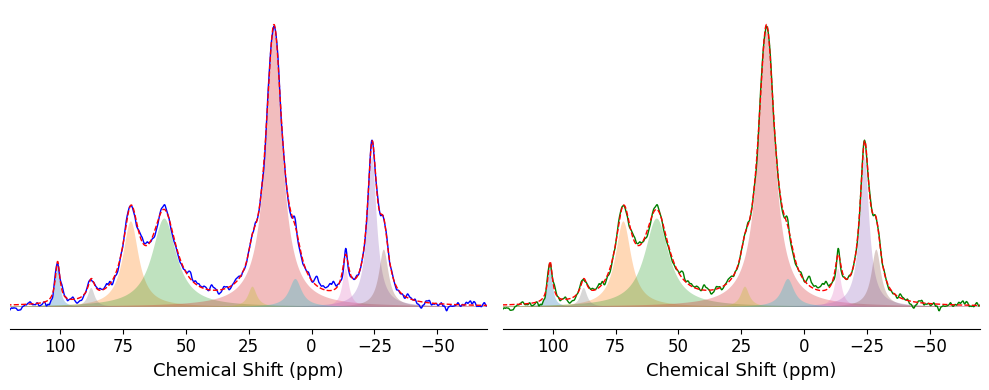

In [5]:
multi_dmfit.plot(
    grid="1x2",
    color=["blue", "green"],
    xlim=(120, -70),
)

## Plotting 2D fits

DMFit also allows fitting of 2D NMR spectra such as this <sup>1</sup>H-<sup>31</sup>P [HETCOR example](https://nmr.cemhti.cnrs-orleans.fr/Dmfit/Howto/2D_Heteronuclear.aspx). To use such data in SpinPlots, you need to export the 2D `spectrum` and the model `fit` in DMFit as `.ppm` files.

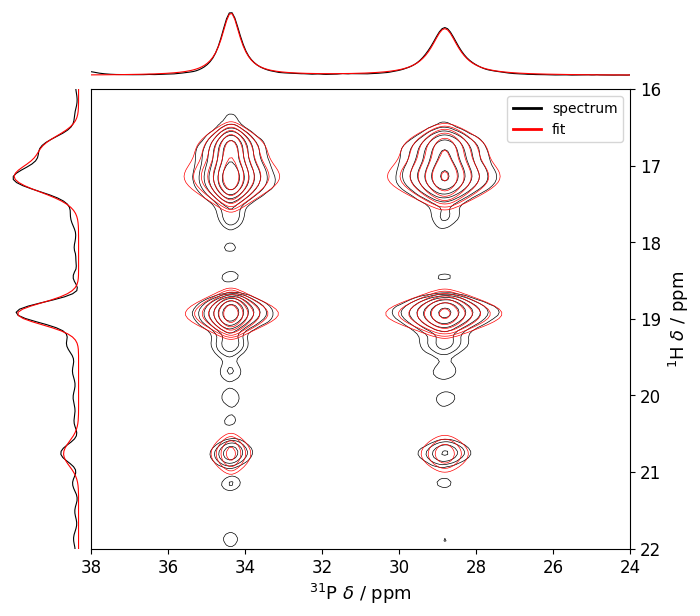

In [8]:
# Read a 2D 1H-31P HETCOR spectrum and fit
hetcor = read_nmr(
    ['../../data/DMFit/hetcor_spectrum.ppm', 
     '../../data/DMFit/hetcor_model.ppm'],
    provider="dmfit",
    tags=["spectrum", "fit"],   
)

hetcor.plot(
    contour_start=10,
    contour_num=25,
    contour_factor=1.5,
    color=['black', 'red'],
    xlim=(38, 24),
    ylim=(22, 16),
    xaxislabel=r"$^{31}$P $\delta$ / ppm",
    yaxislabel=r"$^{1}$H $\delta$ / ppm",
)

### Grid layout for 2D DMFit spectra

For 2D DMFit grid plots, data must be provided in pairs (experimental + model). Use `grid="1x1"` to show a single pair in a subplot with projections. Additional customization options include `linewidth_contour`, `linewidth_proj`, and `diagonal`:

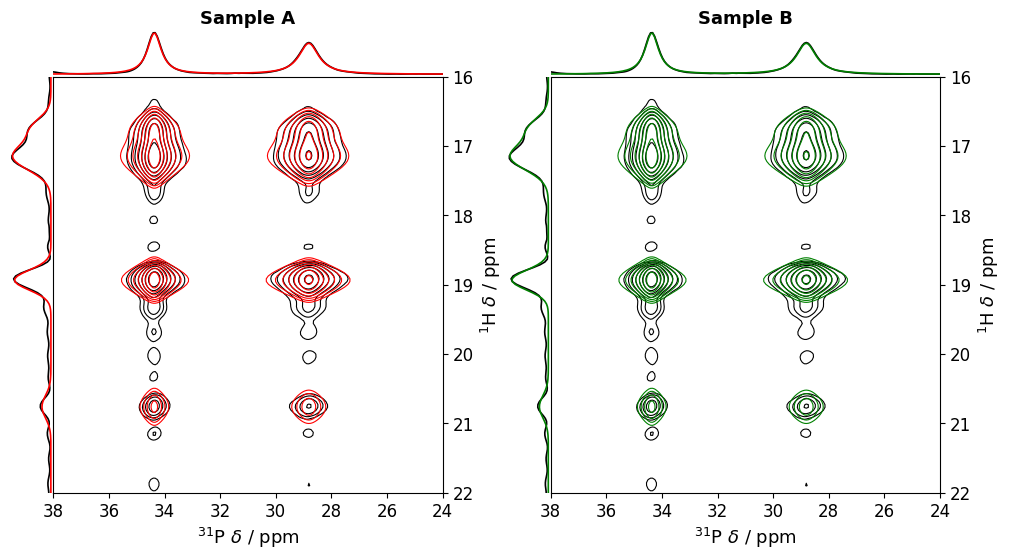

In [12]:
multi_2d = read_nmr(
    ['../../data/DMFit/hetcor_spectrum.ppm', 
     '../../data/DMFit/hetcor_model.ppm',
     '../../data/DMFit/hetcor_spectrum.ppm', 
     '../../data/DMFit/hetcor_model.ppm'],
    provider="dmfit",
    tags=["spectrum A", "fit A", "spectrum B", "fit B"],
)


multi_2d.plot(
    grid="1x2",
    contour_start=10,
    contour_num=15,
    contour_factor=1.5,
    color=[["black", "red"], ["black", "green"]],
    xlim=(38, 24),
    ylim=(22, 16),
    linewidth_contour=0.8,
    linewidth_proj=1.2,
    xaxislabel=r"$^{31}$P $\delta$ / ppm",
    yaxislabel=r"$^{1}$H $\delta$ / ppm",
    titles=["Sample A", "Sample B"],
)